# Задание

Используя шаблон ноутбука для распознавания видов одежды и аксессуаров из набора **fashion_mnist**, выполните следующие действия:

1. Создайте **9 моделей** нейронной сети с различными архитектурами и сравните в них значения точности на проверочной выборке (на последней эпохе) и на тестовой выборке. Используйте следующее деление: обучающая выборка — **50000** примеров, проверочная выборка — **10000** примеров, тестовая выборка — **10000** примеров.
2. Создайте сравнительную таблицу в конце ноутбука, напишите свои выводы по результатам проведённых тестов.


# Шаблон ноутбука

## Импорт библиотек


In [1]:
# Последовательная модель НС
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization

# Колбэк ранней остановки
from tensorflow.keras.callbacks import EarlyStopping

# Утилиты для to_categorical()
from tensorflow.keras import utils

# Алгоритмы оптимизации для обучения модели
from tensorflow.keras.optimizers import Adam, Adadelta

# Библиотека для работы с массивами
import numpy as np

# Библиотека для работы с таблицами
import pandas as pd

# Отрисовка графиков
import matplotlib.pyplot as plt

# Связь с google-диском
from google.colab import files

# Предварительная обработка данных
from sklearn import preprocessing

# Разделение данных на выборки
from sklearn.model_selection import train_test_split

# Для загрузки датасета
from keras.datasets import fashion_mnist

# Отрисовывать изображения в ноутбуке, а не в консоль или файл
%matplotlib inline


## Описание базы

### База: одежда, обувь и аксессуары

- Датасет состоит из набора изображений одежды, обуви, аксессуаров и их классов.
- Изображения одного вида хранятся в numpy-массиве **(28, 28)** — **x_train, x_test**.
- База содержит **10 классов**: (Футболка, Брюки, Пуловер, Платье, Пальто, Сандалии/Босоножки, Рубашка, Кроссовки, Сумочка, Ботильоны) — **y_train, y_test**.
- Примеров: train — **60000**, test — **10000**.

### Вывод примеров


In [2]:
# Загрузка датасета
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Вывод размерностей выборок
print('Размер x_train:', x_train.shape)
print('Размер y_train:', y_train.shape)
print('Размер x_test:', x_test.shape)
print('Размер y_test:', y_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Размер x_train: (60000, 28, 28)
Размер y_train: (60000,)
Размер x_test: (10000, 28, 28)
Размер y_test: (10000,)


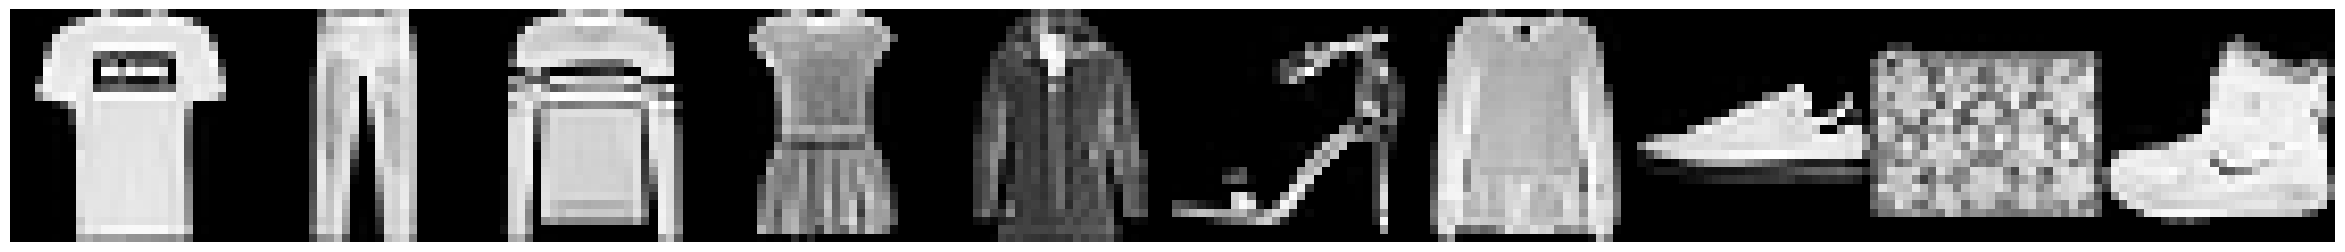

In [3]:
# Выбор 1 изображения каждого класса
imgs = np.array([x_train[y_train==i][0] for i in range(10)])

# Соединение изображения в одну линию
imgs = np.concatenate(imgs, axis=1)

# Создание поля для изображения
plt.figure(figsize=(30, 6))

# Отрисовка итогового изображения
plt.imshow(imgs, cmap='Greys_r')

# Без сетки
plt.grid(False)

# Без осей
plt.axis('off')

# Вывод результата
plt.show()


---

# Решение задания

## Подготовка данных

Согласно заданию, делим выборки так:
- обучающая — **50000** примеров
- проверочная — **10000** примеров
- тестовая — **10000** примеров

В `fashion_mnist` изначально train = 60000, test = 10000. Тестовую берём как есть, а train делим на обучающую (50000) и проверочную (10000) с помощью `train_test_split`.


In [4]:
# Разделение train-выборки на обучающую (50000) и проверочную (10000)
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train,
    test_size=10000,     # ровно 10000 примеров в валидацию
    shuffle=True,        # перемешиваем
    random_state=42      # воспроизводимость
)

print('Обучающая выборка:  ', x_train.shape, y_train.shape)
print('Валидационная:      ', x_val.shape,   y_val.shape)
print('Тестовая:           ', x_test.shape,  y_test.shape)


Обучающая выборка:   (50000, 28, 28) (50000,)
Валидационная:       (10000, 28, 28) (10000,)
Тестовая:            (10000, 28, 28) (10000,)


In [5]:
# Преобразование к формату (N, 784) и нормализация в диапазон [0, 1]
x_train = x_train.reshape(x_train.shape[0], -1).astype('float32') / 255.
x_val   = x_val.reshape(x_val.shape[0], -1).astype('float32') / 255.
x_test  = x_test.reshape(x_test.shape[0], -1).astype('float32') / 255.

# One-hot encoding меток (10 классов)
y_train_cat = utils.to_categorical(y_train, 10)
y_val_cat   = utils.to_categorical(y_val,   10)
y_test_cat  = utils.to_categorical(y_test,  10)

print('x_train:', x_train.shape, ' y_train_cat:', y_train_cat.shape)
print('x_val:  ', x_val.shape,   ' y_val_cat:  ', y_val_cat.shape)
print('x_test: ', x_test.shape,  ' y_test_cat: ', y_test_cat.shape)


x_train: (50000, 784)  y_train_cat: (50000, 10)
x_val:   (10000, 784)  y_val_cat:   (10000, 10)
x_test:  (10000, 784)  y_test_cat:  (10000, 10)


## Вспомогательная функция

Чтобы не дублировать код при обучении 9 моделей, напишем функцию, которая:
- обучает модель с колбэком `EarlyStopping` (останавливает обучение, если `val_loss` перестал улучшаться — это помогает избежать переобучения при слишком большом числе эпох),
- забирает `val_accuracy` на **последней эпохе** (по заданию),
- вычисляет точность на тестовой выборке через `.evaluate()`,
- возвращает результаты для итоговой таблицы.


In [6]:
def train_and_evaluate(model, name, epochs=30, batch_size=256, verbose=0):
    """Обучает модель с EarlyStopping и возвращает точность на val (посл. эпоха) и на test."""

    early_stop = EarlyStopping(
        monitor='val_loss',
        mode='min',
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        x_train, y_train_cat,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=(x_val, y_val_cat),
        callbacks=[early_stop],
        verbose=verbose
    )

    # Точность на валидации на последней эпохе обучения (по заданию)
    val_acc_last = history.history['val_accuracy'][-1]

    # Точность на тесте
    test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

    # Сколько реально прошло эпох (с учётом EarlyStopping)
    epochs_done = len(history.history['loss'])

    print(f'[{name}]  эпох: {epochs_done:>2}   '
          f'val_accuracy (посл. эпоха): {val_acc_last:.4f}   '
          f'test_accuracy: {test_acc:.4f}')

    return {
        'name': name,
        'val_accuracy': val_acc_last,
        'test_accuracy': test_acc,
        'epochs_done': epochs_done,
        'history': history
    }

# Список для результатов всех моделей
results = []


## Модель 1 — однослойная (128 нейронов)

Минимально простая архитектура. Согласно теории — с неё рекомендуется начинать.


In [7]:
model_1 = Sequential()
model_1.add(Dense(128, input_dim=784, activation='relu'))
model_1.add(Dense(10, activation='softmax'))
model_1.compile(loss='categorical_crossentropy',
                optimizer=Adam(learning_rate=0.001),
                metrics=['accuracy'])

results.append(train_and_evaluate(model_1, 'М1: однослойная 128'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[М1: однослойная 128]  эпох: 14   val_accuracy (посл. эпоха): 0.8760   test_accuracy: 0.8765


## Модель 2 — однослойная (256 нейронов)

Та же архитектура, но больше нейронов. Проверим, даёт ли расширение слоя прирост.


In [8]:
model_2 = Sequential()
model_2.add(Dense(256, input_dim=784, activation='relu'))
model_2.add(Dense(10, activation='softmax'))
model_2.compile(loss='categorical_crossentropy',
                optimizer=Adam(learning_rate=0.001),
                metrics=['accuracy'])

results.append(train_and_evaluate(model_2, 'М2: однослойная 256'))


[М2: однослойная 256]  эпох: 20   val_accuracy (посл. эпоха): 0.8903   test_accuracy: 0.8850


## Модель 3 — двуслойная (128 → 64)

Добавляем второй скрытый слой.


In [9]:
model_3 = Sequential()
model_3.add(Dense(128, input_dim=784, activation='relu'))
model_3.add(Dense(64, activation='relu'))
model_3.add(Dense(10, activation='softmax'))
model_3.compile(loss='categorical_crossentropy',
                optimizer=Adam(learning_rate=0.001),
                metrics=['accuracy'])

results.append(train_and_evaluate(model_3, 'М3: двуслойная 128 → 64'))


[М3: двуслойная 128 → 64]  эпох: 17   val_accuracy (посл. эпоха): 0.8860   test_accuracy: 0.8827


## Модель 4 — двуслойная (256 → 128)

Более широкая двуслойная сеть.


In [10]:
model_4 = Sequential()
model_4.add(Dense(256, input_dim=784, activation='relu'))
model_4.add(Dense(128, activation='relu'))
model_4.add(Dense(10, activation='softmax'))
model_4.compile(loss='categorical_crossentropy',
                optimizer=Adam(learning_rate=0.001),
                metrics=['accuracy'])

results.append(train_and_evaluate(model_4, 'М4: двуслойная 256 → 128'))


[М4: двуслойная 256 → 128]  эпох: 17   val_accuracy (посл. эпоха): 0.8871   test_accuracy: 0.8867


## Модель 5 — трёхслойная (512 → 256 → 128)

Глубокая сеть. Проверим, помогает ли рост глубины.


In [11]:
model_5 = Sequential()
model_5.add(Dense(512, input_dim=784, activation='relu'))
model_5.add(Dense(256, activation='relu'))
model_5.add(Dense(128, activation='relu'))
model_5.add(Dense(10, activation='softmax'))
model_5.compile(loss='categorical_crossentropy',
                optimizer=Adam(learning_rate=0.001),
                metrics=['accuracy'])

results.append(train_and_evaluate(model_5, 'М5: трёхслойная 512 → 256 → 128'))


[М5: трёхслойная 512 → 256 → 128]  эпох: 10   val_accuracy (посл. эпоха): 0.8854   test_accuracy: 0.8809


## Модель 6 — с Dropout

Двуслойная 256 → 128 с регуляризацией Dropout. Согласно теории, Dropout случайно отключает часть нейронов в каждом батче — это борьба с переобучением.


In [12]:
model_6 = Sequential()
model_6.add(Dense(256, input_dim=784, activation='relu'))
model_6.add(Dropout(0.3))
model_6.add(Dense(128, activation='relu'))
model_6.add(Dropout(0.3))
model_6.add(Dense(10, activation='softmax'))
model_6.compile(loss='categorical_crossentropy',
                optimizer=Adam(learning_rate=0.001),
                metrics=['accuracy'])

results.append(train_and_evaluate(model_6, 'М6: 256 → Dropout → 128 → Dropout'))


[М6: 256 → Dropout → 128 → Dropout]  эпох: 19   val_accuracy (посл. эпоха): 0.8928   test_accuracy: 0.8869


## Модель 7 — с BatchNormalization

Пакетная нормализация стандартизирует распределение выходов нейронов, позволяет увеличить шаг обучения и уменьшает чувствительность к начальным весам.


In [13]:
model_7 = Sequential()
model_7.add(Dense(256, input_dim=784, activation='relu'))
model_7.add(BatchNormalization())
model_7.add(Dense(128, activation='relu'))
model_7.add(BatchNormalization())
model_7.add(Dense(10, activation='softmax'))
model_7.compile(loss='categorical_crossentropy',
                optimizer=Adam(learning_rate=0.001),
                metrics=['accuracy'])

results.append(train_and_evaluate(model_7, 'М7: 256 → BN → 128 → BN'))


[М7: 256 → BN → 128 → BN]  эпох:  8   val_accuracy (посл. эпоха): 0.8479   test_accuracy: 0.8572


## Модель 8 — Dropout + BatchNormalization

Комбинируем оба инструмента регуляризации на глубокой сети.


In [14]:
model_8 = Sequential()
model_8.add(Dense(512, input_dim=784, activation='relu'))
model_8.add(BatchNormalization())
model_8.add(Dropout(0.3))
model_8.add(Dense(256, activation='relu'))
model_8.add(BatchNormalization())
model_8.add(Dropout(0.3))
model_8.add(Dense(128, activation='relu'))
model_8.add(Dropout(0.2))
model_8.add(Dense(10, activation='softmax'))
model_8.compile(loss='categorical_crossentropy',
                optimizer=Adam(learning_rate=0.001),
                metrics=['accuracy'])

results.append(train_and_evaluate(model_8, 'М8: глубокая + BN + Dropout'))


[М8: глубокая + BN + Dropout]  эпох: 12   val_accuracy (посл. эпоха): 0.8772   test_accuracy: 0.8694


## Модель 9 — другой оптимизатор (Adadelta)

Архитектура как у модели 4 (256 → 128), но оптимизатор — `Adadelta`. Проверим влияние гиперпараметра «алгоритм оптимизации».


In [15]:
model_9 = Sequential()
model_9.add(Dense(256, input_dim=784, activation='relu'))
model_9.add(Dense(128, activation='relu'))
model_9.add(Dense(10, activation='softmax'))
model_9.compile(loss='categorical_crossentropy',
                optimizer=Adadelta(learning_rate=1.0),
                metrics=['accuracy'])

results.append(train_and_evaluate(model_9, 'М9: 256 → 128 (Adadelta)'))


[М9: 256 → 128 (Adadelta)]  эпох:  8   val_accuracy (посл. эпоха): 0.8467   test_accuracy: 0.8663


---

## Сравнительная таблица результатов


In [16]:
# Собираем результаты в DataFrame
df_results = pd.DataFrame([
    {
        '№': i + 1,
        'Архитектура': r['name'],
        'Эпох пройдено': r['epochs_done'],
        'val_accuracy (посл. эпоха)': round(r['val_accuracy'], 4),
        'test_accuracy': round(r['test_accuracy'], 4),
    }
    for i, r in enumerate(results)
])

# Сортировка по точности на тесте
df_results_sorted = df_results.sort_values('test_accuracy', ascending=False).reset_index(drop=True)

print('=== Результаты в порядке добавления ===')
print(df_results.to_string(index=False))
print()
print('=== Результаты, отсортированные по test_accuracy ===')
print(df_results_sorted.to_string(index=False))


=== Результаты в порядке добавления ===
 №                       Архитектура  Эпох пройдено  val_accuracy (посл. эпоха)  test_accuracy
 1               М1: однослойная 128             14                      0.8760         0.8765
 2               М2: однослойная 256             20                      0.8903         0.8850
 3           М3: двуслойная 128 → 64             17                      0.8860         0.8827
 4          М4: двуслойная 256 → 128             17                      0.8871         0.8867
 5   М5: трёхслойная 512 → 256 → 128             10                      0.8854         0.8809
 6 М6: 256 → Dropout → 128 → Dropout             19                      0.8928         0.8869
 7           М7: 256 → BN → 128 → BN              8                      0.8479         0.8572
 8       М8: глубокая + BN + Dropout             12                      0.8772         0.8694
 9          М9: 256 → 128 (Adadelta)              8                      0.8467         0.8663

=== Резул

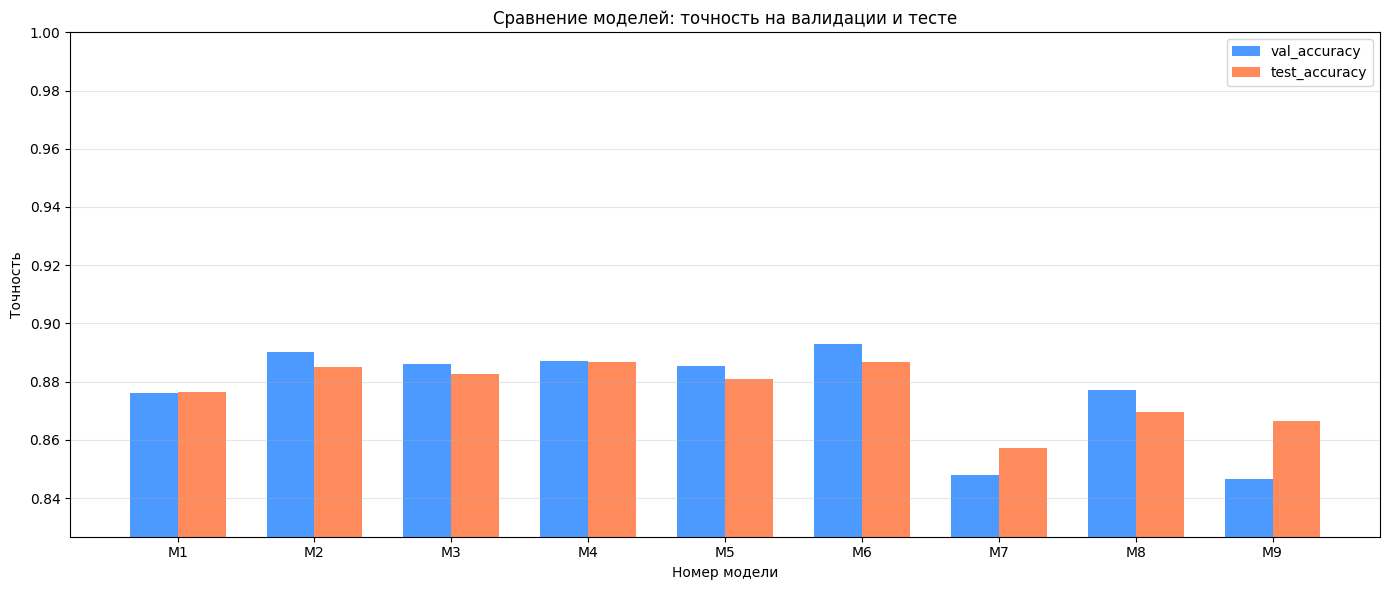

In [17]:
# Визуализация — столбчатая диаграмма
fig, ax = plt.subplots(figsize=(14, 6))

x_pos = np.arange(len(results))
width = 0.35

val_scores  = [r['val_accuracy']  for r in results]
test_scores = [r['test_accuracy'] for r in results]

ax.bar(x_pos - width/2, val_scores,  width, label='val_accuracy',  color='#4C9AFF')
ax.bar(x_pos + width/2, test_scores, width, label='test_accuracy', color='#FF8B5C')

ax.set_xlabel('Номер модели')
ax.set_ylabel('Точность')
ax.set_title('Сравнение моделей: точность на валидации и тесте')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'М{i+1}' for i in range(len(results))])
ax.set_ylim(min(min(val_scores), min(test_scores)) - 0.02, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


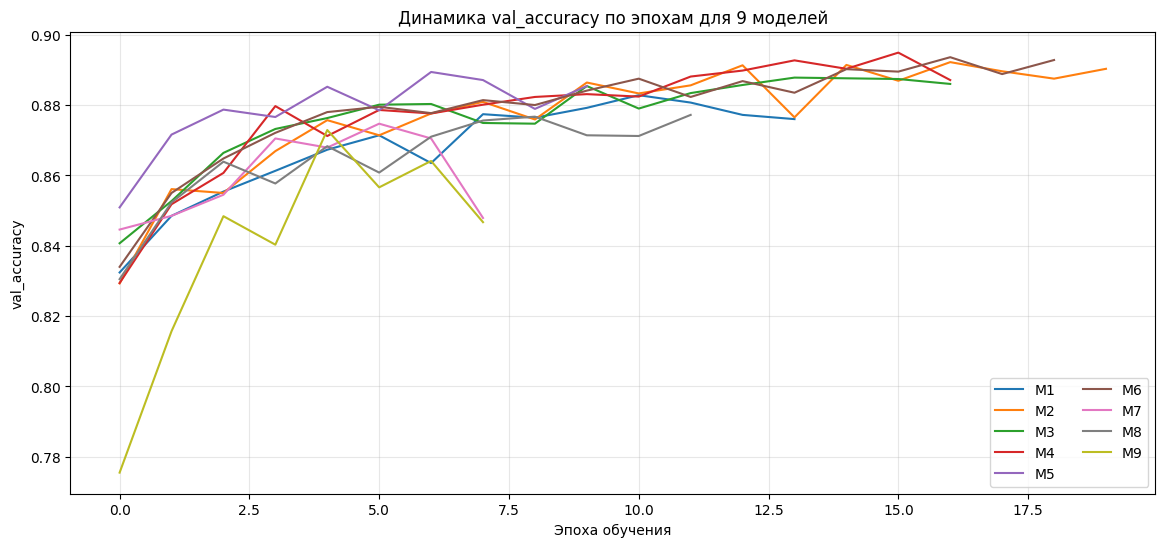

In [18]:
# Графики обучения (val_accuracy по эпохам) для всех моделей
plt.figure(figsize=(14, 6))
for i, r in enumerate(results):
    plt.plot(r['history'].history['val_accuracy'], label=f'М{i+1}')
plt.xlabel('Эпоха обучения')
plt.ylabel('val_accuracy')
plt.title('Динамика val_accuracy по эпохам для 9 моделей')
plt.legend(loc='lower right', ncol=2)
plt.grid(alpha=0.3)
plt.show()
